# Compressor — análise dos sinais

**Pergunta:** quais características do som ajudam a diferenciar Healthy das sete condições de falha?

Dados: 1.800 DAT, 8 classes, 225 arquivos/classe e 50.000 amostras/arquivo.

**Decisões e pendências**

- Adotar fs = 16 kHz pela correspondência com os WAV da MathWorks. Na comparação dos 1.800 pares, DAT/pico absoluto correspondeu ao WAV dentro da precisão de 16 bits. Isso não confirma a taxa original da aquisição.
- Manter as amplitudes dos DAT. Unidade física e calibração não informadas.
- Não sabemos se os arquivos são gravações independentes ou trechos relacionados.
- Por enquanto: exploração dos dados, sem avaliar previsão em gravações novas.

Rodar as etapas 1–25 em ordem. Códigos e saídas foram mantidos; não houve nova execução.

**Fontes:** [IIT Kanpur](https://www.iitk.ac.in/idea/datasets/) · [MathWorks](https://www.mathworks.com/help/signal/ug/data-sets-for-signal-processing.html) · [Verma et al., 2016](https://doi.org/10.1109/TR.2015.2459684) (texto completo ainda não consultado).


## 1. Dados e bibliotecas

Importar as bibliotecas, definir o caminho dos dados e conferir a qtde de arquivos por classe. Esperado: 225 por classe, 1.800 no total.

fs = 16 kHz conforme os WAV correspondentes da MathWorks. A taxa da aquisição original ainda não foi confirmada. Figuras e resultados são salvos a partir da pasta de execução do notebook.


In [ ]:
#mportar as bibliotecas, definir o caminho dos dados e conferir a qtde de arquivos por classe. Esperado: 225 por classe, 1.800 no total.
#fs = 16 kHz conforme os WAV correspondentes da MathWorks. A taxa da aquisição original ainda não foi confirmada. Figuras e resultados são salvos a partir da pasta de execução do notebook.

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from cycler import cycler
from IPython.display import display

# Se você moveu o dataset, substitua pelo caminho que já funcionou.
pasta_dados = Path(
    "/Users/marianabarreto/Downloads/AirCompressor_Data"
)

classes = [
    "Healthy", "Bearing", "Flywheel", "LIV",
    "LOV", "NRV", "Piston", "Riderbelt"
]

# Taxa adotada conforme a versão correspondente da MathWorks.
# A taxa de aquisição original permanece sem confirmação.
fs = 16_000

pasta_figuras = Path("figuras")
pasta_resultados = Path("resultados")

pasta_figuras.mkdir(exist_ok=True)
pasta_resultados.mkdir(exist_ok=True)

for classe in classes:
    pasta_classe = pasta_dados / classe

    if not pasta_classe.is_dir():
        raise FileNotFoundError(f"Pasta não encontrada: {pasta_classe}")

    quantidade = len(list(pasta_classe.glob("*.dat")))
    print(f"{classe}: {quantidade} arquivos")

Healthy: 225 arquivos
Bearing: 225 arquivos
Flywheel: 225 arquivos
LIV: 225 arquivos
LOV: 225 arquivos
NRV: 225 arquivos
Piston: 225 arquivos
Riderbelt: 225 arquivos


## 2. Estilo dos gráficos

Configuração de fonte, cores, eixos e grade. Salvar cada fig. em PDF e PNG de 600 dpi. Rodar antes de gerar os gráficos.


In [53]:
MM = 1 / 25.4

COLORS = [
    "#14304A", "#6C8FA8", "#8C3A26", "#B4C0C8",
    "#2C3E4C", "#A39A6B", "#767676", "#000000"
]

MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]

fontes_disponiveis = {
    fonte.name for fonte in fm.fontManager.ttflist
}

fonte = (
    "Latin Modern Roman"
    if "Latin Modern Roman" in fontes_disponiveis
    else "DejaVu Serif"
)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [fonte],
    "font.size": 11,
    "mathtext.fontset": "cm",
    "text.usetex": False,

    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 1.8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.axisbelow": True,
    "axes.xmargin": 0.06,
    "axes.ymargin": 0.09,
    "axes.prop_cycle": (
        cycler(color=COLORS) + cycler(marker=MARKERS)
    ),

    "lines.markeredgecolor": "black",
    "lines.markeredgewidth": 1.1,

    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    "axes.grid": True,
    "axes.grid.which": "major",
    "grid.color": "black",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 1.0,

    "figure.figsize": (190 * MM, 120 * MM),
    "figure.constrained_layout.use": True,
    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.08,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def configurar_grade(ax):
    ax.minorticks_on()

    ax.grid(
        True, which="major",
        linestyle="--", linewidth=0.6, color="black"
    )

    ax.grid(
        True, which="minor",
        linestyle=":", linewidth=0.4, color="gray"
    )


def salvar_figura(fig, nome):
    fig.savefig(
        pasta_figuras / f"{nome}.pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        pasta_figuras / f"{nome}.png",
        dpi=600,
        bbox_inches="tight"
    )


print(f"Fonte utilizada: {fonte}")

Fonte utilizada: DejaVu Serif


## 3. Carregar Healthy

Ler a gravação 1 da classe Healthy e montar o vetor de tempo: t = n/fs. São 50.000 amostras, equivalentes a 3,125 s na taxa adotada. Manter a amplitude do DAT.


In [54]:
arquivo = pasta_dados / "Healthy" / "preprocess_Reading1.dat"

sinal = np.loadtxt(arquivo, delimiter=",").ravel()
tempo = np.arange(sinal.size) / fs

print(f"Arquivo: {arquivo.name}")
print(f"Número de amostras: {sinal.size}")
print(f"Frequência adotada: {fs} Hz")
print(f"Duração na taxa adotada: {sinal.size / fs:.3f} s")

Arquivo: preprocess_Reading1.dat
Número de amostras: 50000
Frequência adotada: 16000 Hz
Duração na taxa adotada: 3.125 s


## 4. Sinal Healthy

Olhar as oscilações e os picos de uma gravação saudável. É só um exemplo da classe.

Obs.: o eixo está como Amplitude [-], mas a unidade não foi informada. Corrigir esse rótulo na versão final.


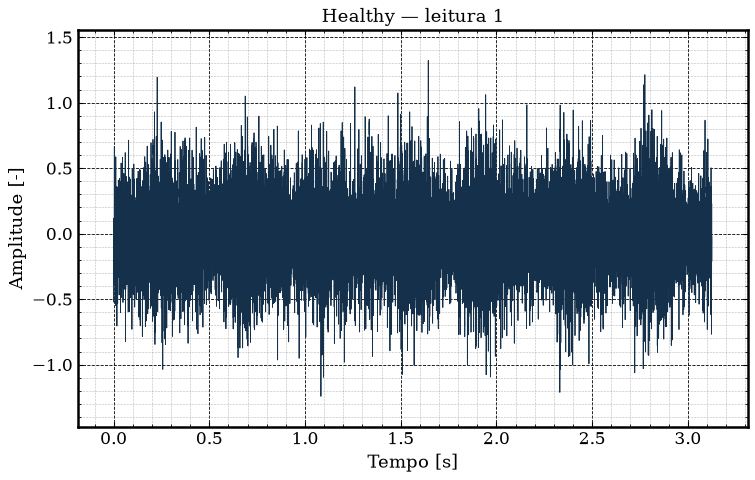

In [55]:
fig, ax = plt.subplots()

ax.plot(
    tempo,
    sinal,
    marker="none",
    linestyle="-",
    linewidth=0.6
)

ax.set_title("Healthy — leitura 1")
ax.set_xlabel("Tempo [s]")
ax.set_ylabel("Amplitude [-]")

configurar_grade(ax)

salvar_figura(fig, "sinal_healthy")
plt.show()

## 5. Um sinal de cada classe

Comparar a leitura 1 das oito classes com a mesma escala. Serve para uma primeira inspeção; depois precisamos olhar todos os arquivos. A unidade da amplitude continua desconhecida.


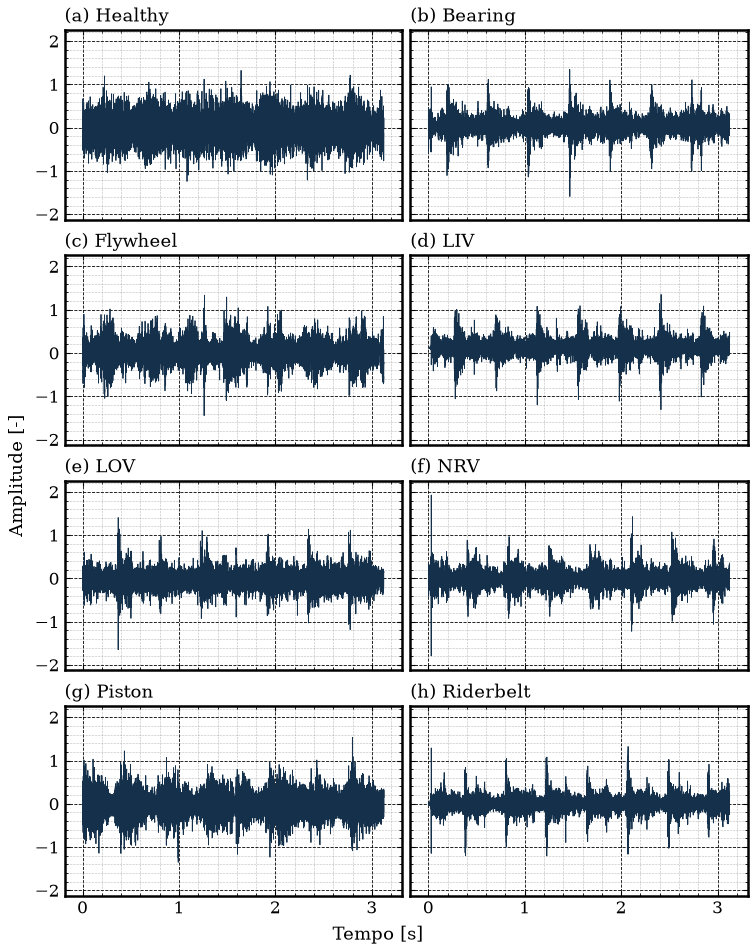

In [56]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(190 * MM, 240 * MM),
    sharex=True,
    sharey=True
)

for i, (ax, classe) in enumerate(zip(axes.flat, classes)):
    arquivo = pasta_dados / classe / "preprocess_Reading1.dat"

    valores = np.loadtxt(arquivo, delimiter=",").ravel()
    tempo_classe = np.arange(valores.size) / fs

    ax.plot(
        tempo_classe,
        valores,
        marker="none",
        linestyle="-",
        linewidth=0.6
    )

    ax.set_title(
        f"({chr(97 + i)}) {classe}",
        loc="left"
    )

    configurar_grade(ax)

fig.supxlabel("Tempo [s]", fontsize=13)
fig.supylabel("Amplitude [-]", fontsize=13)

salvar_figura(fig, "sinais_por_classe")
plt.show()

## 6. Medidas no tempo

Calcular média, RMS e desvio padrão de cada sinal.

- Média: deslocamento em relação a zero.
- RMS: magnitude geral.
- Desvio padrão: oscilação em torno da média.

Aqui usamos ddof=0, então RMS² = média² + desvio padrão². Salvar uma linha por arquivo em medidas_temporais.csv.


In [57]:
import pandas as pd

resultados = []

for classe in classes:
    arquivos = sorted(
        (pasta_dados / classe).glob("*.dat"),
        key=lambda arquivo: int(
            arquivo.stem.replace("preprocess_Reading", "")
        )
    )

    for arquivo in arquivos:
        valores = np.loadtxt(arquivo, delimiter=",").ravel()

        resultados.append({
            "classe": classe,
            "arquivo": arquivo.name,
            "amostras": valores.size,
            "media": np.mean(valores),
            "rms": np.sqrt(np.mean(valores**2)),
            "desvio_padrao": np.std(valores, ddof=0),
        })

    print(f"{classe}: {len(arquivos)} sinais processados")

df = pd.DataFrame(resultados)

df.to_csv(
    pasta_resultados / "medidas_temporais.csv",
    index=False
)

print(f"\nTotal: {len(df)} sinais")
display(df.head())

Healthy: 225 sinais processados
Bearing: 225 sinais processados
Flywheel: 225 sinais processados
LIV: 225 sinais processados
LOV: 225 sinais processados
NRV: 225 sinais processados
Piston: 225 sinais processados
Riderbelt: 225 sinais processados

Total: 1800 sinais


,classe,arquivo,amostras,media,rms,desvio_padrao
0,Healthy,preprocess_Reading1.dat,50000,-0.010666,0.280724,0.280521
1,Healthy,preprocess_Reading2.dat,50000,-0.016872,0.274890,0.274372
2,Healthy,preprocess_Reading3.dat,50000,-0.012098,0.268435,0.268162
3,Healthy,preprocess_Reading4.dat,50000,-0.015105,0.254899,0.254451
4,Healthy,preprocess_Reading5.dat,50000,-0.020796,0.264810,0.263992


## 7. Resumo por classe

Calcular a média e o desvio padrão das medidas entre os 225 arquivos. O std desta tabela é a variação entre gravações, não dentro de um sinal. Aqui o pandas usa ddof=1.


In [58]:
resumo = (
    df.groupby("classe")[["media", "rms", "desvio_padrao"]]
    .agg(["mean", "std"])
    .reindex(classes)
)

resumo.to_csv(
    pasta_resultados / "resumo_por_classe.csv"
)

display(resumo.round(5))

media               rms          desvio_padrao         
              mean      std     mean      std          mean      std
classe                                                              
Healthy    0.00421  0.03142  0.26092  0.01383       0.25899  0.01398
Bearing    0.04675  0.04472  0.23381  0.01848       0.22460  0.01965
Flywheel   0.00156  0.04771  0.23210  0.01928       0.22710  0.01998
LIV        0.06274  0.04104  0.20578  0.02222       0.19211  0.01784
LOV        0.03900  0.04852  0.23048  0.02001       0.22185  0.02103
NRV       -0.00700  0.04477  0.19284  0.01416       0.18750  0.01355
Piston     0.01574  0.04562  0.22878  0.02007       0.22357  0.02096
Riderbelt  0.00460  0.03938  0.19558  0.01889       0.19151  0.01921

## 8. Boxplots

Comparar as distribuições das medidas. Linha central = mediana; caixa = 50% central dos valores. Pontos fora das hastes são extremos pelo critério de 1,5 × intervalo interquartil, não necessariamente erros. Ver dispersão e sobreposição entre classes. Revisar o rótulo de amplitude [-].


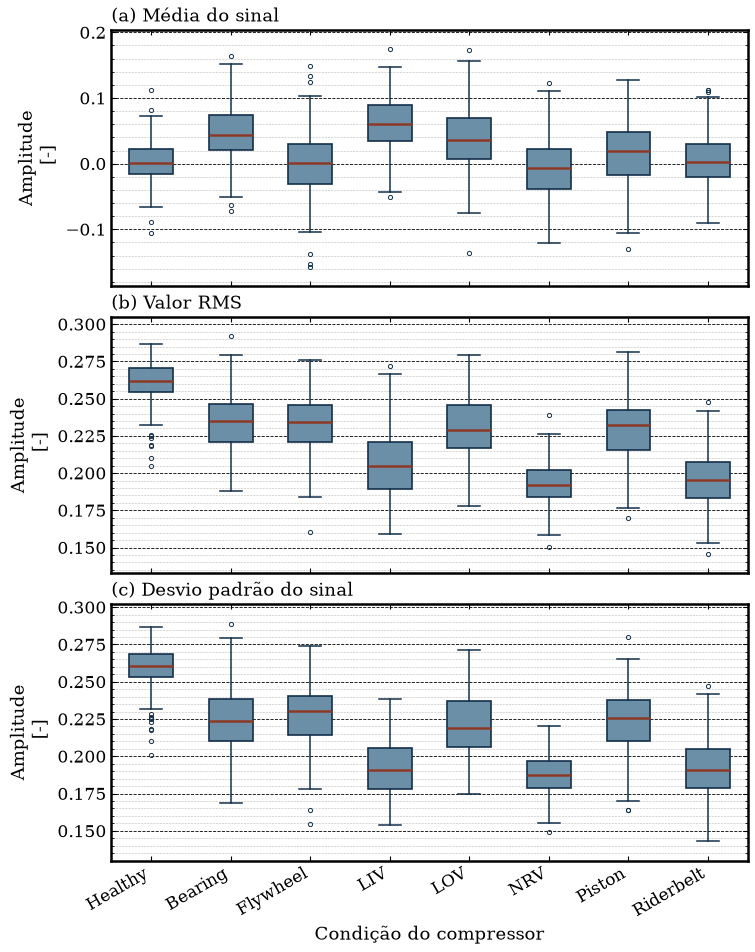

In [59]:
medidas = [
    ("media", "Média do sinal"),
    ("rms", "Valor RMS"),
    ("desvio_padrao", "Desvio padrão do sinal"),
]

fig, axes = plt.subplots(
    3, 1,
    figsize=(190 * MM, 240 * MM),
    sharex=True
)

for i, (ax, (coluna, titulo)) in enumerate(zip(axes, medidas)):
    dados = [
        df.loc[df["classe"] == classe, coluna].to_numpy()
        for classe in classes
    ]

    caixas = ax.boxplot(
        dados,
        positions=np.arange(1, len(classes) + 1),
        widths=0.55,
        patch_artist=True,
        showfliers=True,
        whis=1.5,
        boxprops={
            "facecolor": COLORS[1],
            "edgecolor": COLORS[0],
            "linewidth": 1.2,
        },
        medianprops={
            "color": COLORS[2],
            "linewidth": 1.8,
        },
        whiskerprops={
            "color": COLORS[0],
            "linewidth": 1.1,
        },
        capprops={
            "color": COLORS[0],
            "linewidth": 1.1,
        },
        flierprops={
            "marker": "o",
            "markersize": 3,
            "markerfacecolor": "none",
            "markeredgecolor": COLORS[0],
            "markeredgewidth": 0.7,
        },
    )

    ax.set_title(
        f"({chr(97 + i)}) {titulo}",
        loc="left"
    )

    ax.set_ylabel("Amplitude\n [-]")
    ax.set_xticks(np.arange(1, len(classes) + 1))
    ax.set_xticklabels(classes, rotation=30, ha="right")

    configurar_grade(ax)

    # O eixo horizontal contém categorias, não valores contínuos.
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.grid(False, axis="x", which="both")

axes[-1].set_xlabel("Condição do compressor")

salvar_figura(fig, "distribuicoes_medidas_temporais")
plt.show()

## 9. PSD por Welch

Estimar como a potência do sinal se distribui em frequência. Welch combina espectros de trechos do sinal para reduzir a variação da estimativa.

Janela Hann, 4.096 amostras, 50% de sobreposição e remoção da média por trecho. Com fs = 16 kHz: trecho de 0,256 s e espaçamento de 3,90625 Hz entre pontos. Esse espaçamento não é a resolução efetiva da janela. Parâmetros ainda exploratórios; potência aqui não significa potência mecânica em W.


In [60]:
from scipy.signal import welch

espectros_por_classe = {}

for classe in classes:
    arquivos = sorted((pasta_dados / classe).glob("*.dat"))
    espectros = []

    for arquivo in arquivos:
        valores = np.loadtxt(arquivo, delimiter=",").ravel()

        frequencias, psd = welch(
            valores,
            fs=fs,
            window="hann",
            nperseg=4096,
            noverlap=2048,
            detrend="constant",
            scaling="density"
        )

        espectros.append(psd)

    espectros_por_classe[classe] = np.asarray(espectros)
    print(f"{classe}: {len(espectros)} espectros calculados")

np.savez_compressed(
    pasta_resultados / "espectros_welch.npz",
    frequencias=frequencias,
    **espectros_por_classe
)

Healthy: 225 espectros calculados
Bearing: 225 espectros calculados
Flywheel: 225 espectros calculados
LIV: 225 espectros calculados
LOV: 225 espectros calculados
NRV: 225 espectros calculados
Piston: 225 espectros calculados
Riderbelt: 225 espectros calculados


## 10. PSD das classes

Plotar mediana e percentis 25–75 em cada frequência. A faixa mostra variação entre arquivos, não intervalo de confiança. Escala log no eixo y. Ver picos e regiões com maior potência, sem associar diretamente a uma falha física ainda.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


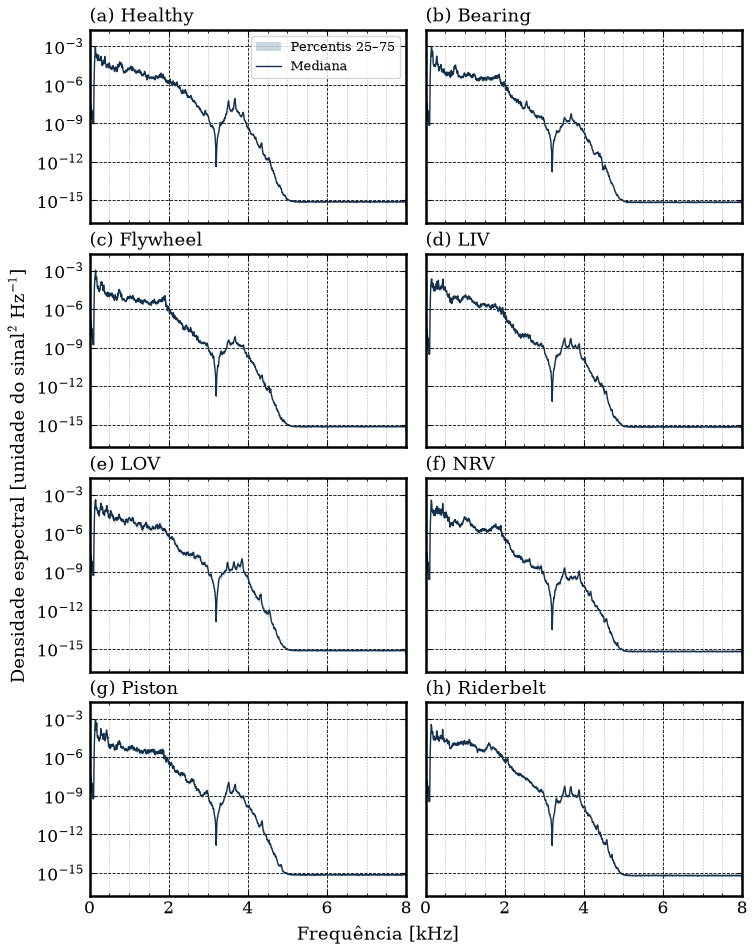

In [61]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(190 * MM, 240 * MM),
    sharex=True,
    sharey=True
)

# Excluir frequência zero para representar as oscilações.
mascara = frequencias > 0
f = frequencias[mascara]

for i, (ax, classe) in enumerate(zip(axes.flat, classes)):
    espectros = espectros_por_classe[classe][:, mascara]

    q25, mediana, q75 = np.percentile(
        espectros, [25, 50, 75], axis=0
    )

    ax.fill_between(
        f,
        q25,
        q75,
        color=COLORS[1],
        alpha=0.35,
        linewidth=0,
        label="Percentis 25–75"
    )

    ax.plot(
        f,
        mediana,
        marker="none",
        linestyle="-",
        linewidth=1.0,
        label="Mediana"
    )

    ax.set_yscale("log")
    ax.set_xlim(0, fs / 2)
    ax.set_xticks([0, 2000, 4000, 6000, 8000])
    ax.set_xticklabels(["0", "2", "4", "6", "8"])

    ax.set_title(
        f"({chr(97 + i)}) {classe}",
        loc="left"
    )

    configurar_grade(ax)

axes.flat[0].legend(loc="best", fontsize=9)

fig.supxlabel("Frequência [kHz]", fontsize=13)
fig.supylabel(
    r"Densidade espectral [unidade do sinal$^2$ Hz$^{-1}$]",
    fontsize=13
)

salvar_figura(fig, "espectros_welch_por_classe")
plt.show()

## 11. Potência por banda

Somar a PSD × Δf em cada banda e dividir pelo total. Obtemos a fração de potência por faixa; as cinco frações somam ~1.

Bandas escolhidas para exploração, sem ligação comprovada com frequências de falha. Juntar as tabelas por classe + arquivo para não misturar gravações com o mesmo nome.


In [62]:
bandas = [
    (0, 500),
    (500, 1000),
    (1000, 2000),
    (2000, 4000),
    (4000, 8000),
]

resultados_espectrais = []

# Espaçamento entre os pontos de frequência.
delta_f = frequencias[1] - frequencias[0]

for classe in classes:
    # Mesma ordem utilizada na célula 9.
    arquivos = sorted((pasta_dados / classe).glob("*.dat"))
    espectros = espectros_por_classe[classe]

    if len(arquivos) != len(espectros):
        raise ValueError(f"Quantidade incompatível para {classe}")

    for arquivo, psd in zip(arquivos, espectros):
        potencia_total = np.sum(psd) * delta_f

        linha = {
            "classe": classe,
            "arquivo": arquivo.name,
            "potencia_total_welch": potencia_total,
        }

        for inicio, fim in bandas:
            # Intervalos sem sobreposição.
            mascara = (
                (frequencias >= inicio)
                & (frequencias < fim)
            )

            # Incluir o ponto de Nyquist na última banda.
            if fim == fs / 2:
                mascara = (
                    (frequencias >= inicio)
                    & (frequencias <= fim)
                )

            potencia_banda = np.sum(psd[mascara]) * delta_f

            linha[f"fracao_{inicio}_{fim}"] = (
                potencia_banda / potencia_total
                if potencia_total > 0 else np.nan
            )

        resultados_espectrais.append(linha)

df_espectral = pd.DataFrame(resultados_espectrais)

# Associar as características pelo arquivo e pela classe.
df_features = df.merge(
    df_espectral,
    on=["classe", "arquivo"],
    how="left",
    validate="one_to_one"
)

df_features.to_csv(
    pasta_resultados / "caracteristicas_temporais_espectrais.csv",
    index=False
)

display(df_features.head())

,classe,arquivo,amostras,media,rms,desvio_padrao,potencia_total_welch,fracao_0_500,fracao_500_1000,fracao_1000_2000,fracao_2000_4000,fracao_4000_8000
0,Healthy,preprocess_Reading1.dat,50000,-0.010666,0.280724,0.280521,0.079247,0.526921,0.240464,0.222849,0.009766,6.809522e-07
1,Healthy,preprocess_Reading2.dat,50000,-0.016872,0.274890,0.274372,0.072456,0.563238,0.259572,0.168512,0.008678,6.405590e-07
2,Healthy,preprocess_Reading3.dat,50000,-0.012098,0.268435,0.268162,0.071113,0.593996,0.226851,0.170536,0.008616,6.422762e-07
3,Healthy,preprocess_Reading4.dat,50000,-0.015105,0.254899,0.254451,0.063969,0.634169,0.223226,0.135029,0.007575,5.930657e-07
4,Healthy,preprocess_Reading5.dat,50000,-0.020796,0.264810,0.263992,0.071990,0.710372,0.171161,0.112536,0.005931,5.584676e-07


## 12. Comparação das bandas

Cada barra mostra a média das frações da classe. Comparar onde a potência se concentra. Não mostra amplitude absoluta nem dispersão entre arquivos.


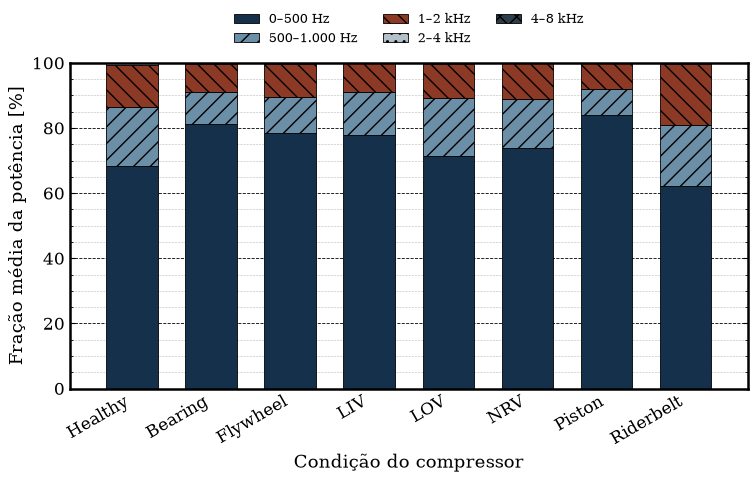

In [63]:
colunas_bandas = [
    f"fracao_{inicio}_{fim}"
    for inicio, fim in bandas
]

# Média das frações individuais dos 225 sinais de cada classe.
percentuais = (
    df_features
    .groupby("classe")[colunas_bandas]
    .mean()
    .reindex(classes)
    * 100
)

fig, ax = plt.subplots(
    figsize=(190 * MM, 120 * MM)
)

posicoes = np.arange(len(classes))
base = np.zeros(len(classes))

hachuras = ["", "//", "\\\\", "..", "xx"]
rotulos = [
    "0–500 Hz",
    "500–1.000 Hz",
    "1–2 kHz",
    "2–4 kHz",
    "4–8 kHz",
]

for i, (coluna, rotulo) in enumerate(
    zip(colunas_bandas, rotulos)
):
    valores = percentuais[coluna].to_numpy()

    ax.bar(
        posicoes,
        valores,
        bottom=base,
        width=0.65,
        color=COLORS[i],
        edgecolor="black",
        linewidth=0.6,
        hatch=hachuras[i],
        label=rotulo
    )

    base += valores

ax.set_xticks(posicoes)
ax.set_xticklabels(classes, rotation=30, ha="right")

ax.set_ylim(0, 100)
ax.set_ylabel("Fração média da potência [%]")
ax.set_xlabel("Condição do compressor")

configurar_grade(ax)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.grid(False, axis="x", which="both")

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    fontsize=9,
    frameon=False
)

salvar_figura(fig, "potencia_relativa_por_banda")
plt.show()

## 13. Preparar o PCA

Usar média, desvio padrão e quatro frações espectrais. Retirar RMS pela relação com as medidas temporais e a quinta fração porque as outras já a determinam. Ainda pode haver redundância.

Padronizar cada coluna: z = (x − média)/desvio padrão, com ddof=1. Evita domínio por escala, mas dá peso também às características de pouca variação absoluta. Usamos todos os dados: análise exploratória, sem teste em dados novos.


In [64]:
caracteristicas_pca = [
    "media",
    "desvio_padrao",
    "fracao_0_500",
    "fracao_500_1000",
    "fracao_1000_2000",
    "fracao_2000_4000",
]

X = df_features[caracteristicas_pca].to_numpy(dtype=float)

if not np.isfinite(X).all():
    raise ValueError("Existem valores ausentes ou infinitos nas características.")

media_features = X.mean(axis=0)
escala_features = X.std(axis=0, ddof=1)

if np.any(escala_features == 0):
    raise ValueError("Existe uma característica constante.")

X_padronizado = (X - media_features) / escala_features

print(f"Matriz: {X_padronizado.shape[0]} sinais × "
      f"{X_padronizado.shape[1]} características")

Matriz: 1800 sinais × 6 características


## 14. PCA via SVD

Decompor Z = UΣVᵀ. As coordenadas são UΣ e os pesos são as colunas de V. Variância de cada componente = s²/(n−1).

O PCA usa as características, sem os rótulos das classes. Salvar coordenadas, pesos e parâmetros.


In [65]:
U, S, Vt = np.linalg.svd(
    X_padronizado,
    full_matrices=False
)

# Coordenadas dos sinais nos componentes principais.
scores = U * S

# Variância de cada componente.
variancia = S**2 / (X_padronizado.shape[0] - 1)
fracao_variancia = variancia / variancia.sum()
variancia_acumulada = np.cumsum(fracao_variancia)

nomes_componentes = [
    f"PC{i + 1}" for i in range(len(S))
]

tabela_variancia = pd.DataFrame({
    "componente": nomes_componentes,
    "variancia_explicada_percentual": 100 * fracao_variancia,
    "variancia_acumulada_percentual": 100 * variancia_acumulada,
})

df_scores = df_features[["classe", "arquivo"]].copy()
df_scores[nomes_componentes] = scores

# Pesos das características em cada direção principal.
pesos_pca = pd.DataFrame(
    Vt.T,
    index=caracteristicas_pca,
    columns=nomes_componentes
)

tabela_variancia.to_csv(
    pasta_resultados / "pca_variancia.csv",
    index=False
)

df_scores.to_csv(
    pasta_resultados / "pca_coordenadas.csv",
    index=False
)

pesos_pca.to_csv(
    pasta_resultados / "pca_pesos.csv"
)

np.savez_compressed(
    pasta_resultados / "pca_parametros.npz",
    caracteristicas=np.array(caracteristicas_pca),
    media=media_features,
    escala=escala_features,
    Vt=Vt,
    valores_singulares=S
)

display(tabela_variancia.round(2))

,componente,variancia_explicada_percentual,variancia_acumulada_percentual
0,PC1,50.88,50.88
1,PC2,24.30,75.18
2,PC3,15.61,90.80
3,PC4,5.01,95.80
4,PC5,4.20,100.00
5,PC6,0.00,100.00


## 15. Variância explicada

Barras = variância de cada componente; curva = acumulada. Ver quantos componentes precisamos manter. Não confundir variância explicada com acurácia.


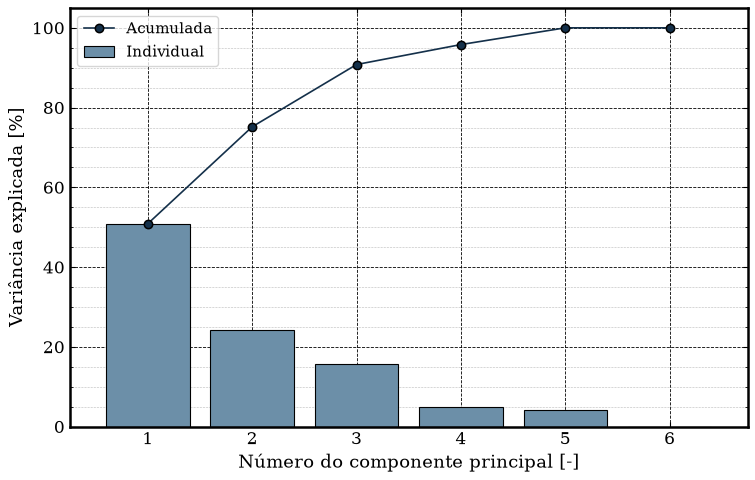

In [66]:
fig, ax = plt.subplots()

posicoes = np.arange(1, len(S) + 1)

ax.bar(
    posicoes,
    100 * fracao_variancia,
    color=COLORS[1],
    edgecolor="black",
    linewidth=0.8,
    label="Individual"
)

ax.plot(
    posicoes,
    100 * variancia_acumulada,
    color=COLORS[0],
    marker="o",
    linestyle="-",
    linewidth=1.2,
    label="Acumulada"
)

ax.set_xticks(posicoes)
ax.set_xlabel("Número do componente principal [-]")
ax.set_ylabel("Variância explicada [%]")
ax.set_ylim(0, 105)

configurar_grade(ax)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.legend()

salvar_figura(fig, "pca_variancia_explicada")
plt.show()

## 16. PC1 × PC2

Cada ponto é uma gravação. As classes só entram nas cores e nos símbolos. Ver grupos e sobreposições. A projeção pode esconder diferenças dos outros componentes; não é uma avaliação de diagnóstico.


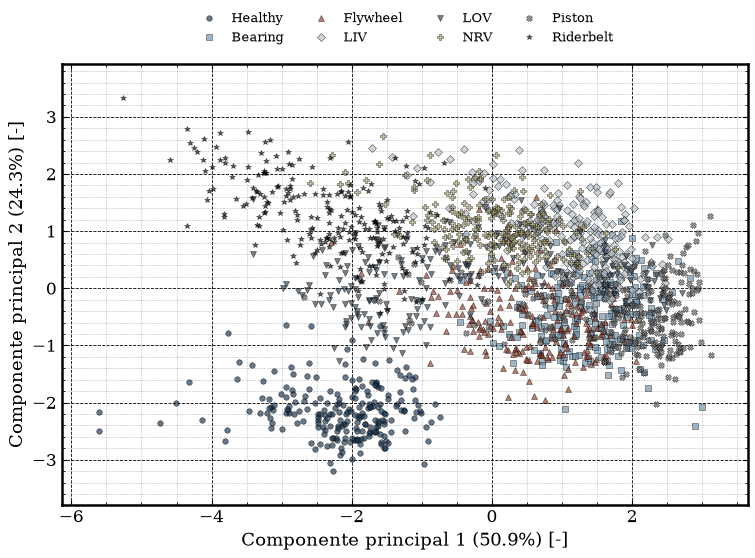

Variância preservada em dois componentes: 75.18%


In [67]:
fig, ax = plt.subplots(
    figsize=(190 * MM, 140 * MM)
)

for i, classe in enumerate(classes):
    selecao = df_scores["classe"] == classe

    ax.plot(
        df_scores.loc[selecao, "PC1"],
        df_scores.loc[selecao, "PC2"],
        linestyle="none",
        marker=MARKERS[i],
        color=COLORS[i],
        markersize=4,
        markeredgewidth=0.4,
        alpha=0.65,
        label=classe
    )

ax.set_xlabel(
    f"Componente principal 1 "
    f"({100 * fracao_variancia[0]:.1f}%) [-]"
)

ax.set_ylabel(
    f"Componente principal 2 "
    f"({100 * fracao_variancia[1]:.1f}%) [-]"
)

configurar_grade(ax)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    fontsize=9,
    frameon=False
)

salvar_figura(fig, "pca_classes")
plt.show()

print(
    "Variância preservada em dois componentes: "
    f"{100 * variancia_acumulada[1]:.2f}%"
)

## 17. Wavelet

Retirar a média e aplicar db4, 6 níveis, com periodization nas bordas. A6 contém a aproximação mais lenta; D1, os detalhes mais rápidos.

Calcular a soma dos coeficientes² em cada nível e dividir pela soma total. São frações de energia dos coeficientes, com influência das bordas. Ao resumir por energia, perdemos a localização dos eventos no tempo. db4 e 6 níveis ainda são escolhas exploratórias.

Obs.: a linha de instalação do PyWavelets só precisa ser executada quando necessário.


In [68]:
%pip install PyWavelets
import pywt

wavelet = "db4"
nivel = 6

# wavedec retorna os coeficientes nesta ordem.
nomes_wavelet = [
    "A6", "D6", "D5", "D4", "D3", "D2", "D1"
]

resultados_wavelet = []

for classe in classes:
    arquivos = sorted((pasta_dados / classe).glob("*.dat"))

    for arquivo in arquivos:
        valores = np.loadtxt(arquivo, delimiter=",").ravel()
        valores_centrados = valores - valores.mean()

        coeficientes = pywt.wavedec(
            valores_centrados,
            wavelet=wavelet,
            level=nivel,
            mode="periodization"
        )

        energias = np.array([
            np.sum(coef**2) for coef in coeficientes
        ])

        energia_total = energias.sum()

        if energia_total <= 0:
            raise ValueError(f"Sinal sem oscilação: {arquivo}")

        fracoes = energias / energia_total

        linha = {
            "classe": classe,
            "arquivo": arquivo.name,
        }

        for nome, fracao in zip(nomes_wavelet, fracoes):
            linha[f"wavelet_{nome}"] = fracao

        resultados_wavelet.append(linha)

    print(f"{classe}: {len(arquivos)} sinais processados")

df_wavelet = pd.DataFrame(resultados_wavelet)

df_features_completo = df_features.merge(
    df_wavelet,
    on=["classe", "arquivo"],
    how="left",
    validate="one_to_one"
)

df_features_completo.to_csv(
    pasta_resultados / "caracteristicas_com_wavelet.csv",
    index=False
)

display(df_wavelet.head())


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Healthy: 225 sinais processados
Bearing: 225 sinais processados
Flywheel: 225 sinais processados
LIV: 225 sinais processados
LOV: 225 sinais processados
NRV: 225 sinais processados
Piston: 225 sinais processados
Riderbelt: 225 sinais processados


,classe,arquivo,wavelet_A6,wavelet_D6,wavelet_D5,wavelet_D4,wavelet_D3,wavelet_D2,wavelet_D1
0,Healthy,preprocess_Reading1.dat,0.046048,0.258617,0.221278,0.215437,0.213584,0.044254,0.000782
1,Healthy,preprocess_Reading10.dat,0.057965,0.326670,0.252076,0.208182,0.137502,0.017243,0.000362
2,Healthy,preprocess_Reading100.dat,0.059937,0.393448,0.234928,0.170293,0.122980,0.018022,0.000391
3,Healthy,preprocess_Reading101.dat,0.053055,0.379434,0.253558,0.174475,0.121601,0.017479,0.000398
4,Healthy,preprocess_Reading102.dat,0.066764,0.370766,0.254007,0.181409,0.111401,0.015326,0.000328


## 18. Energia Wavelet por classe

Comparar a fração média de energia em cada nível. Ver se as classes concentram energia em escalas diferentes. O gráfico não mostra a dispersão e pode repetir informação das bandas da PSD.


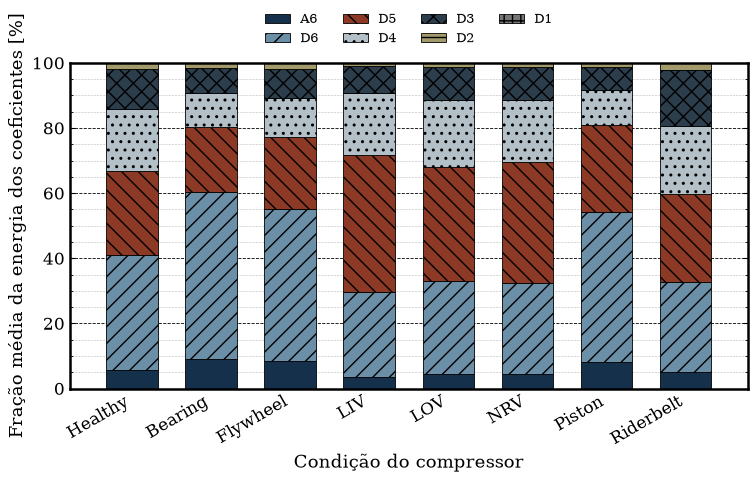

In [69]:
colunas_wavelet = [
    f"wavelet_{nome}" for nome in nomes_wavelet
]

percentuais_wavelet = (
    df_wavelet
    .groupby("classe")[colunas_wavelet]
    .mean()
    .reindex(classes)
    * 100
)

fig, ax = plt.subplots(
    figsize=(190 * MM, 120 * MM)
)

posicoes = np.arange(len(classes))
base = np.zeros(len(classes))
hachuras = ["", "//", "\\\\", "..", "xx", "--", "++"]

for i, nome in enumerate(nomes_wavelet):
    valores = percentuais_wavelet[f"wavelet_{nome}"].to_numpy()

    ax.bar(
        posicoes,
        valores,
        bottom=base,
        width=0.65,
        color=COLORS[i],
        edgecolor="black",
        linewidth=0.6,
        hatch=hachuras[i],
        label=nome
    )

    base += valores

ax.set_xticks(posicoes)
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.set_ylim(0, 100)

ax.set_xlabel("Condição do compressor")
ax.set_ylabel("Fração média da energia dos coeficientes [%]")

configurar_grade(ax)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.grid(False, axis="x", which="both")

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    fontsize=9,
    frameon=False
)

salvar_figura(fig, "energia_wavelet_por_classe")
plt.show()

## 19. PCA com e sem Wavelet

Comparar 6 características com 12. Usar D1–D6 e omitir A6, pois as sete frações somam 1. Padronizar cada conjunto separadamente.

Adicionar Wavelet aumenta o peso desse bloco e pode repetir informação espectral. A escolha de qual fração omitir também influencia a representação.


In [70]:
conjuntos_pca = {
    "Temporal + espectral": caracteristicas_pca,
    "Temporal + espectral + Wavelet": (
        caracteristicas_pca
        + [f"wavelet_D{i}" for i in range(1, 7)]
    ),
}

comparacao_pca = {}

for nome, colunas in conjuntos_pca.items():
    matriz = df_features_completo[colunas].to_numpy(dtype=float)

    if not np.isfinite(matriz).all():
        raise ValueError(f"Valores ausentes ou infinitos em: {nome}")

    medias = matriz.mean(axis=0)
    escalas = matriz.std(axis=0, ddof=1)

    if np.any(escalas == 0):
        raise ValueError(f"Característica constante em: {nome}")

    matriz_padronizada = (matriz - medias) / escalas

    u, s, vt = np.linalg.svd(
        matriz_padronizada,
        full_matrices=False
    )

    coordenadas = u * s
    fracao = s**2 / np.sum(s**2)

    comparacao_pca[nome] = {
        "colunas": colunas,
        "scores": coordenadas,
        "fracao_variancia": fracao,
        "pesos": vt.T,
    }

    print(
        f"{nome}: {len(colunas)} características | "
        f"PC1 + PC2: {100 * fracao[:2].sum():.2f}% da variância"
    )

Temporal + espectral: 6 características | PC1 + PC2: 75.18% da variância
Temporal + espectral + Wavelet: 12 características | PC1 + PC2: 76.86% da variância


## 20. Comparar as projeções

Ver como os grupos mudam com Wavelet. Os eixos dos dois PCA são diferentes, então suas coordenadas não são diretamente equivalentes. Separação visual maior não comprova melhora de classificação.


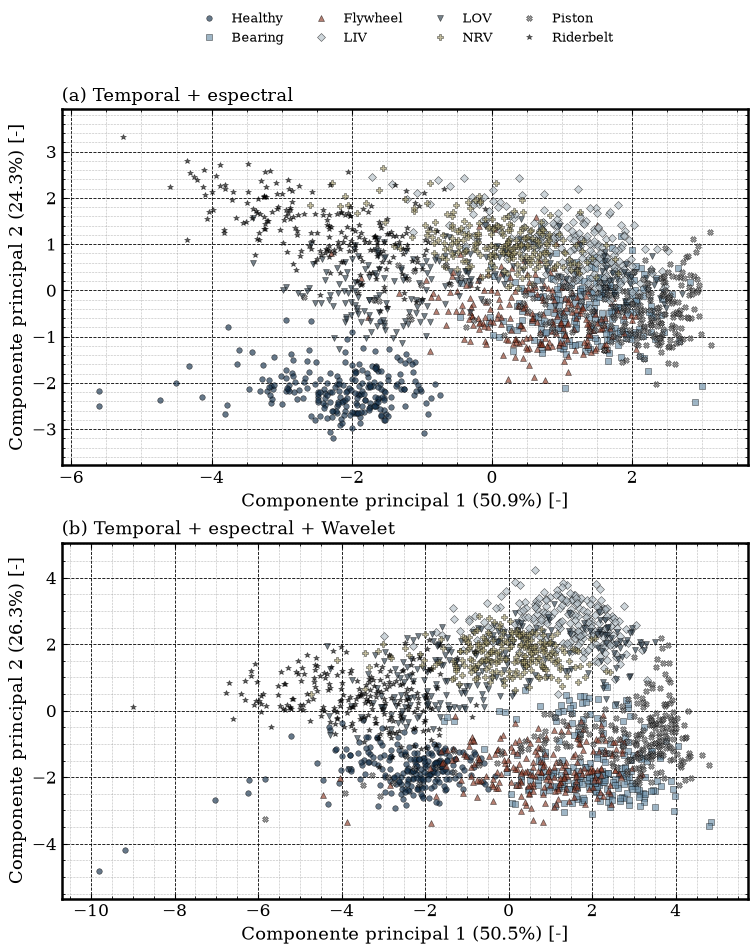

In [71]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(190 * MM, 240 * MM)
)

rotulos = df_features_completo["classe"].to_numpy()

for painel, (ax, (nome, resultado)) in enumerate(
    zip(axes, comparacao_pca.items())
):
    coordenadas = resultado["scores"]
    fracao = resultado["fracao_variancia"]

    for i, classe in enumerate(classes):
        selecao = rotulos == classe

        ax.plot(
            coordenadas[selecao, 0],
            coordenadas[selecao, 1],
            linestyle="none",
            marker=MARKERS[i],
            color=COLORS[i],
            markersize=4,
            markeredgewidth=0.4,
            alpha=0.65,
            label=classe
        )

    ax.set_title(
        f"({chr(97 + painel)}) {nome}",
        loc="left"
    )

    ax.set_xlabel(
        f"Componente principal 1 ({100 * fracao[0]:.1f}%) [-]"
    )
    ax.set_ylabel(
        f"Componente principal 2 ({100 * fracao[1]:.1f}%) [-]"
    )

    configurar_grade(ax)

axes[0].legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    fontsize=9,
    frameon=False
)

salvar_figura(fig, "comparacao_pca_com_wavelet")
plt.show()

## 21. Resumo dos PCA

Registrar a variância em PC1 + PC2 e quantos componentes atingem 90%. É uma medida de redução dimensional. Não usar a diferença de percentuais entre os conjuntos como ganho de acurácia.


In [72]:
linhas_resumo = []

for numero, (nome, resultado) in enumerate(
    comparacao_pca.items(), start=1
):
    fracao = resultado["fracao_variancia"]
    acumulada = np.cumsum(fracao)

    linhas_resumo.append({
        "analise": nome,
        "numero_caracteristicas": len(resultado["colunas"]),
        "variancia_PC1_PC2_percentual": 100 * acumulada[1],
        "componentes_para_90_percentual": (
            np.searchsorted(acumulada, 0.90) + 1
        ),
    })

    coordenadas_df = df_features_completo[
        ["classe", "arquivo"]
    ].copy()

    nomes_pc = [
        f"PC{i + 1}"
        for i in range(resultado["scores"].shape[1])
    ]

    coordenadas_df[nomes_pc] = resultado["scores"]

    coordenadas_df.to_csv(
        pasta_resultados / f"comparacao_pca_{numero}_coordenadas.csv",
        index=False
    )

    pd.DataFrame(
        resultado["pesos"],
        index=resultado["colunas"],
        columns=nomes_pc
    ).to_csv(
        pasta_resultados / f"comparacao_pca_{numero}_pesos.csv"
    )

resumo_comparacao = pd.DataFrame(linhas_resumo)

resumo_comparacao.to_csv(
    pasta_resultados / "comparacao_pca_resumo.csv",
    index=False
)

display(resumo_comparacao.round(2))

,analise,numero_caracteristicas,variancia_PC1_PC2_percentual,componentes_para_90_percentual
0,Temporal + espectral,6,75.18,3
1,Temporal + espectral + Wavelet,12,76.86,4


## 22. Correlação

Calcular Pearson e listar os pares com maior |r|. Perto de ±1: forte relação linear; perto de 0: pouca relação linear, não independência.

A correlação junta todas as classes e pode refletir diferenças entre grupos. Frações que somam 1 também geram dependências. Não excluir características só por esse número.


In [73]:
colunas_analise = conjuntos_pca[
    "Temporal + espectral + Wavelet"
]

rotulos_caracteristicas = {
    "media": "Média",
    "desvio_padrao": "Desvio padrão",
    "fracao_0_500": "PSD: 0–500 Hz",
    "fracao_500_1000": "PSD: 500–1.000 Hz",
    "fracao_1000_2000": "PSD: 1–2 kHz",
    "fracao_2000_4000": "PSD: 2–4 kHz",
    **{f"wavelet_D{i}": f"Wavelet D{i}" for i in range(1, 7)},
}

correlacao = df_features_completo[colunas_analise].corr()

correlacao.to_csv(
    pasta_resultados / "correlacao_caracteristicas.csv"
)

pares = []

for i, primeira in enumerate(colunas_analise):
    for segunda in colunas_analise[i + 1:]:
        r = correlacao.loc[primeira, segunda]

        pares.append({
            "caracteristica_1": rotulos_caracteristicas[primeira],
            "caracteristica_2": rotulos_caracteristicas[segunda],
            "correlacao": r,
            "correlacao_absoluta": abs(r),
        })

pares_correlacao = (
    pd.DataFrame(pares)
    .sort_values("correlacao_absoluta", ascending=False)
    .reset_index(drop=True)
)

pares_correlacao.to_csv(
    pasta_resultados / "pares_correlacao.csv",
    index=False
)

display(pares_correlacao.head(10).round(3))

,caracteristica_1,caracteristica_2,correlacao,correlacao_absoluta
0,PSD: 1–2 kHz,Wavelet D3,0.987,0.987
1,PSD: 0–500 Hz,Wavelet D3,-0.934,0.934
2,PSD: 0–500 Hz,PSD: 500–1.000 Hz,-0.925,0.925
3,Wavelet D1,Wavelet D2,0.924,0.924
4,PSD: 0–500 Hz,PSD: 1–2 kHz,-0.908,0.908
5,Wavelet D4,Wavelet D6,-0.898,0.898
6,PSD: 500–1.000 Hz,Wavelet D4,0.882,0.882
7,PSD: 1–2 kHz,Wavelet D2,0.863,0.863
8,Wavelet D2,Wavelet D3,0.852,0.852
9,PSD: 0–500 Hz,Wavelet D4,-0.794,0.794


## 23. Matriz de correlação

Ver blocos de características que variam juntas, principalmente PSD × Wavelet. Diagonal = 1. Cores mostram o sinal e a intensidade da correlação.


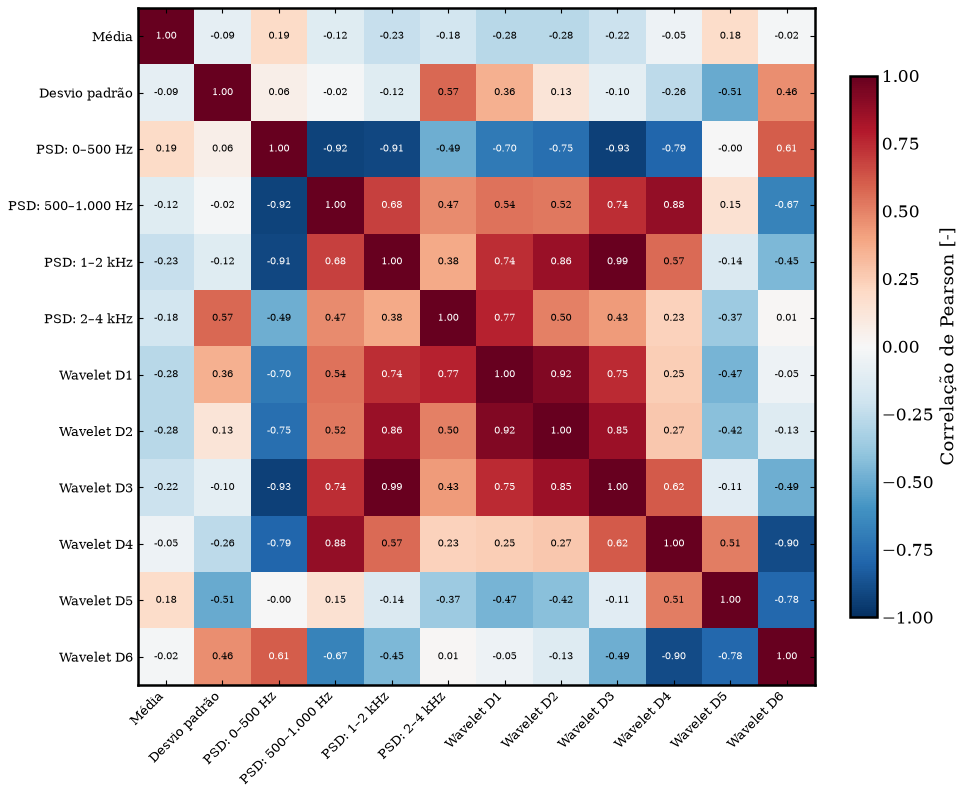

In [74]:
rotulos = [
    rotulos_caracteristicas[coluna]
    for coluna in colunas_analise
]

fig, ax = plt.subplots(
    figsize=(240 * MM, 200 * MM)
)

imagem = ax.imshow(
    correlacao.to_numpy(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

ax.set_xticks(np.arange(len(rotulos)))
ax.set_yticks(np.arange(len(rotulos)))

ax.set_xticklabels(
    rotulos,
    rotation=45,
    ha="right",
    fontsize=9
)

ax.set_yticklabels(rotulos, fontsize=9)

# A grade usual não se aplica a esta matriz.
ax.grid(False, which="both")
ax.minorticks_off()

valores_correlacao = correlacao.to_numpy()

for i in range(len(rotulos)):
    for j in range(len(rotulos)):
        valor = valores_correlacao[i, j]

        ax.text(
            j, i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if abs(valor) > 0.6 else "black"
        )

barra = fig.colorbar(imagem, ax=ax, shrink=0.8)
barra.set_label("Correlação de Pearson [-]")

salvar_figura(fig, "correlacao_caracteristicas")
plt.show()

## 24. Pesos do PCA

Ver quais características têm maior peso em PC1 e PC2. Maior magnitude = maior participação na direção, não importância para prever falhas. O sinal indica o sentido da combinação; inverter o componente inteiro não muda a solução.


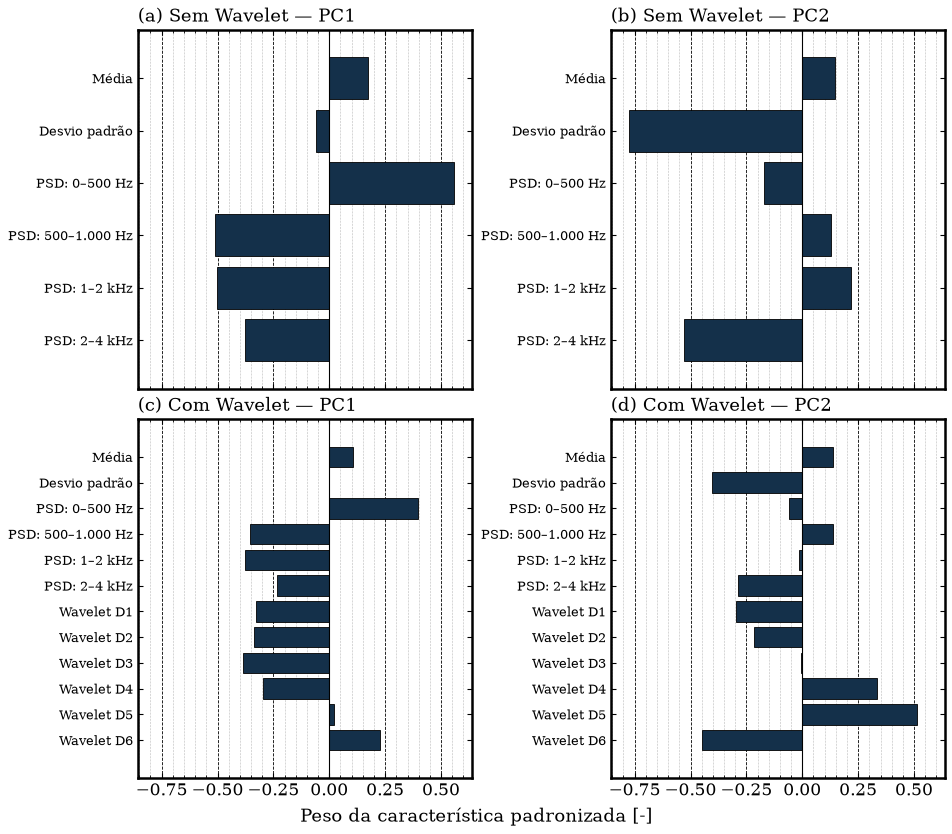

In [75]:
tabelas_pesos = {}

fig, axes = plt.subplots(
    2, 2,
    figsize=(240 * MM, 210 * MM),
    sharex=True
)

for linha, (nome, resultado) in enumerate(
    comparacao_pca.items()
):
    colunas = resultado["colunas"]
    pesos = resultado["pesos"]

    tabela = pd.DataFrame(
        pesos[:, :2],
        index=colunas,
        columns=["PC1", "PC2"]
    )

    tabelas_pesos[nome] = tabela

    tabela.to_csv(
        pasta_resultados / f"pesos_PC1_PC2_modelo_{linha + 1}.csv"
    )

    for componente in range(2):
        ax = axes[linha, componente]
        valores = pesos[:, componente]
        posicoes = np.arange(len(colunas))

        ax.barh(
            posicoes,
            valores,
            color=COLORS[0],
            edgecolor="black",
            linewidth=0.6
        )

        ax.set_yticks(posicoes)
        ax.set_yticklabels(
            [rotulos_caracteristicas[c] for c in colunas],
            fontsize=9
        )
        ax.invert_yaxis()

        ax.axvline(0, color="black", linewidth=0.8)

        ax.set_title(
            f"({chr(97 + linha * 2 + componente)}) "
            f"{'Sem Wavelet' if linha == 0 else 'Com Wavelet'}"
            f" — PC{componente + 1}",
            loc="left"
        )

        configurar_grade(ax)
        ax.yaxis.set_minor_locator(plt.NullLocator())
        ax.grid(False, axis="y", which="both")

fig.supxlabel(
    "Peso da característica padronizada [-]",
    fontsize=13
)

salvar_figura(fig, "pesos_componentes_principais")
plt.show()

## 25. Silhouette

Medir a separação usando as classes conhecidas e distância euclidiana.

a = distância média à própria classe; b = menor distância média a outra classe. s = (b−a)/máx(a,b).

- Perto de +1: boa separação.
- Perto de 0: pouca separação.
- Negativo: maior proximidade média a outra classe.

Comparar características completas e PC1/PC2. Depende da escala, das características e do formato dos grupos. Não é acurácia nem teste de significância.


In [77]:
%pip install scikit-learn
from sklearn.metrics import silhouette_samples

rotulos_classes = df_features_completo["classe"].to_numpy()

resumos_separacao = []
separacao_por_classe = []
separacao_por_sinal = []

for nome, resultado in comparacao_pca.items():
    matriz = df_features_completo[
        resultado["colunas"]
    ].to_numpy(dtype=float)

    matriz_padronizada = (
        (matriz - matriz.mean(axis=0))
        / matriz.std(axis=0, ddof=1)
    )

    representacoes = {
        "Características completas": matriz_padronizada,
        "PC1 e PC2": resultado["scores"][:, :2],
    }

    for representacao, dados in representacoes.items():
        valores_silhouette = silhouette_samples(
            dados,
            rotulos_classes,
            metric="euclidean"
        )

        resumos_separacao.append({
            "analise": nome,
            "representacao": representacao,
            "silhouette_medio": valores_silhouette.mean(),
            "percentual_negativo": (
                100 * np.mean(valores_silhouette < 0)
            ),
        })

        for classe in classes:
            valores_classe = valores_silhouette[
                rotulos_classes == classe
            ]

            separacao_por_classe.append({
                "analise": nome,
                "representacao": representacao,
                "classe": classe,
                "silhouette_medio": valores_classe.mean(),
            })

        registro = df_features_completo[
            ["classe", "arquivo"]
        ].copy()

        registro["analise"] = nome
        registro["representacao"] = representacao
        registro["silhouette"] = valores_silhouette

        separacao_por_sinal.append(registro)

df_separacao = pd.DataFrame(resumos_separacao)
df_separacao_classes = pd.DataFrame(separacao_por_classe)

df_separacao.to_csv(
    pasta_resultados / "silhouette_resumo.csv",
    index=False
)

df_separacao_classes.to_csv(
    pasta_resultados / "silhouette_por_classe.csv",
    index=False
)

pd.concat(separacao_por_sinal, ignore_index=True).to_csv(
    pasta_resultados / "silhouette_por_sinal.csv",
    index=False
)

display(df_separacao.round(3))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 4.2 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,analise,representacao,silhouette_medio,percentual_negativo
0,Temporal + espectral,Características completas,0.134,31.000
1,Temporal + espectral,PC1 e PC2,0.111,38.778
2,Temporal + espectral + Wavelet,Características completas,0.181,23.833
3,Temporal + espectral + Wavelet,PC1 e PC2,0.114,35.222


##Resultado parcial 
A inclusão das características Wavelet aumentou o silhouette médio de 0,134 para 0,181 no espaço completo e reduziu a proporção de valores negativos de 31,00% para 23,83%. A separação entre classes, porém, esta limitada. Em PC1 e PC2, o índice passou de 0,111 para 0,114, indicando pouca mudança na separação da projeção 2D.

A matriz de correlação mostrou redundância entre características espectrais e Wavelet, principalmente entre a fração PSD de 1–2 kHz e D3 (r = 0,987). Portanto, o aumento do silhouette pode envolver tanto informação complementar quanto uma mudança no peso de informações semelhantes.

Os pesos do PCA indicam que PC1 representa principalmente contrastes na distribuição espectral. Com Wavelet, os níveis D4–D6 também participam da formação de PC2. Os resultados são exploratórios e não representam desempenho de classificação em dados novos.


Comparar a separação das classes com 2, 3 e 4 PCs e no espaço completo, incluindo um teste sem D3 para avaliar o efeito dessa característica redundante.

In [78]:
from sklearn.metrics import silhouette_samples

cenarios = {
    "Temporal + espectral": list(caracteristicas_pca),

    "Com Wavelet": list(
        conjuntos_pca["Temporal + espectral + Wavelet"]
    ),

    "Com Wavelet, sem D3": [
        coluna
        for coluna in conjuntos_pca[
            "Temporal + espectral + Wavelet"
        ]
        if coluna != "wavelet_D3"
    ],
}

rotulos_classes = df_features_completo["classe"].to_numpy()

resultados_sensibilidade = []
resultados_sensibilidade_classes = []

for nome, colunas in cenarios.items():
    matriz = df_features_completo[colunas].to_numpy(dtype=float)

    if not np.isfinite(matriz).all():
        raise ValueError(f"Valores inválidos em: {nome}")

    escala = matriz.std(axis=0, ddof=1)

    if np.any(escala == 0):
        raise ValueError(f"Característica constante em: {nome}")

    z = (matriz - matriz.mean(axis=0)) / escala

    u, s, vt = np.linalg.svd(z, full_matrices=False)
    scores_teste = u * s
    variancia_acumulada = np.cumsum(s**2 / np.sum(s**2))

    representacoes = [
        ("2 PCs", scores_teste[:, :2], 2, variancia_acumulada[1]),
        ("3 PCs", scores_teste[:, :3], 3, variancia_acumulada[2]),
        ("4 PCs", scores_teste[:, :4], 4, variancia_acumulada[3]),
        ("Completo", z, len(colunas), 1.0),
    ]

    for representacao, dados, dimensoes, variancia_retida in representacoes:
        valores = silhouette_samples(
            dados,
            rotulos_classes,
            metric="euclidean"
        )

        resultados_sensibilidade.append({
            "cenario": nome,
            "representacao": representacao,
            "dimensoes": dimensoes,
            "variancia_retida_percentual": 100 * variancia_retida,
            "silhouette_medio": valores.mean(),
            "percentual_negativo": 100 * np.mean(valores < 0),
        })

        for classe in classes:
            selecao = rotulos_classes == classe

            resultados_sensibilidade_classes.append({
                "cenario": nome,
                "representacao": representacao,
                "classe": classe,
                "silhouette_medio": valores[selecao].mean(),
            })

    print(f"Concluído: {nome}")

df_sensibilidade = pd.DataFrame(resultados_sensibilidade)

df_sensibilidade_classes = pd.DataFrame(
    resultados_sensibilidade_classes
)

df_sensibilidade.to_csv(
    pasta_resultados / "sensibilidade_pca.csv",
    index=False
)

df_sensibilidade_classes.to_csv(
    pasta_resultados / "sensibilidade_pca_por_classe.csv",
    index=False
)

display(df_sensibilidade.round(3))

Concluído: Temporal + espectral
Concluído: Com Wavelet
Concluído: Com Wavelet, sem D3


,cenario,representacao,dimensoes,variancia_retida_percentual,silhouette_medio,percentual_negativo
0,Temporal + espectral,2 PCs,2,75.180,0.111,38.778
1,Temporal + espectral,3 PCs,3,90.795,0.122,34.722
2,Temporal + espectral,4 PCs,4,95.802,0.130,32.556
3,Temporal + espectral,Completo,6,100.000,0.134,31.000
4,Com Wavelet,2 PCs,2,76.856,0.114,35.222
5,Com Wavelet,3 PCs,3,86.127,0.190,27.778
6,Com Wavelet,4 PCs,4,93.464,0.187,25.833
7,Com Wavelet,Completo,12,100.000,0.181,23.833
8,"Com Wavelet, sem D3",2 PCs,2,75.812,0.122,34.111
9,"Com Wavelet, sem D3",3 PCs,3,85.436,0.196,26.778


Comparar os valores de silhouette dos três cenários para ver como o nº de componentes e a retirada de D3 afetam a separação das classes.

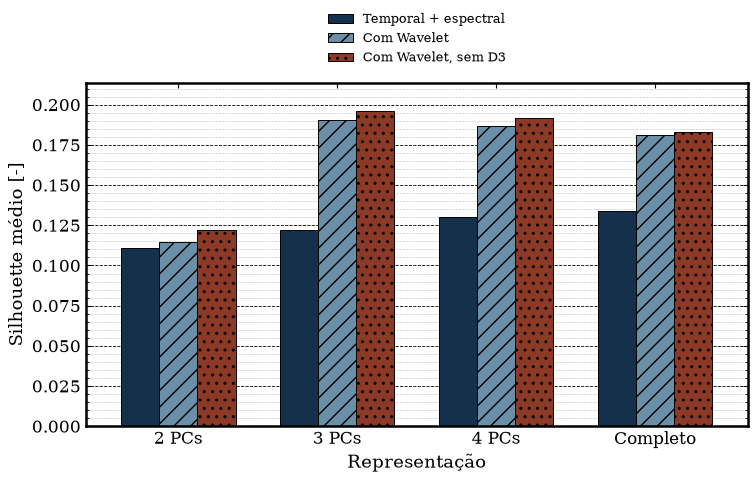

In [79]:
ordem = ["2 PCs", "3 PCs", "4 PCs", "Completo"]

tabela_silhouette = (
    df_sensibilidade
    .pivot(
        index="representacao",
        columns="cenario",
        values="silhouette_medio"
    )
    .reindex(ordem)
)

fig, ax = plt.subplots()

posicoes = np.arange(len(ordem))
largura = 0.24

for i, nome in enumerate(cenarios):
    ax.bar(
        posicoes + (i - 1) * largura,
        tabela_silhouette[nome].to_numpy(),
        width=largura,
        color=COLORS[i],
        edgecolor="black",
        linewidth=0.7,
        hatch=["", "//", ".."][i],
        label=nome
    )

ax.set_xticks(posicoes)
ax.set_xticklabels(ordem)
ax.set_xlabel("Representação")
ax.set_ylabel("Silhouette médio [-]")
ax.axhline(0, color="black", linewidth=0.8)

configurar_grade(ax)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.grid(False, axis="x", which="both")

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    fontsize=9,
    frameon=False
)

salvar_figura(fig, "sensibilidade_pca_silhouette")
plt.show()

## Sensibilidade do PCA
Com Wavelet, o silhouette aumentou principalmente ao passar de 2 para 3 PCs (0,114 → 0,190), indicando que a projeção 2D oculta parte da separação. A retirada de D3 produziu pequenas melhorias, coerentes com sua alta correlação com a fração PSD de 1–2 kHz.

O maior silhouette observado foi 0,196, com Wavelet sem D3 e 3 PCs, retendo 85,44% da variância. Porém, o espaço completo apresentou menor percentual de valores negativos. Assim, preservar mais variância não garantiu maior silhouette, e nenhum cenário foi superior nos dois critérios. As diferenças são exploratórias e a separação entre classes permanece limitada.

Comparar o silhouette por classe para identificar quais condições apresentam maior separação e quais continuam sobrepostas.

In [80]:
comparacao_classes = (
    df_sensibilidade_classes
    .pivot(
        index="classe",
        columns=["cenario", "representacao"],
        values="silhouette_medio"
    )
    .reindex(classes)
)

# Comparar os três cenários usando 3 PCs.
tabela_classes = comparacao_classes.loc[
    :,
    [
        ("Temporal + espectral", "3 PCs"),
        ("Com Wavelet", "3 PCs"),
        ("Com Wavelet, sem D3", "3 PCs"),
    ]
].copy()

tabela_classes.columns = [
    "Temporal + espectral",
    "Com Wavelet",
    "Com Wavelet, sem D3",
]

tabela_classes.to_csv(
    pasta_resultados / "comparacao_classes_3pcs.csv"
)

display(tabela_classes.round(3))

,Temporal + espectral,Com Wavelet,"Com Wavelet, sem D3"
classe,,,
Healthy,0.577,0.582,0.572
Bearing,0.025,0.046,0.051
Flywheel,-0.005,0.064,0.092
LIV,0.090,0.289,0.308
LOV,-0.203,-0.189,-0.188
NRV,0.160,0.262,0.290
Piston,0.008,0.028,0.032
Riderbelt,0.327,0.443,0.414


Calcular o erro de reconstrução com diferentes nº de componentes para avaliar a perda causada pela redução dimensional em sdv

In [81]:
resultados_reconstrucao = []

for nome, colunas in cenarios.items():
    matriz = df_features_completo[colunas].to_numpy(dtype=float)

    z = (
        (matriz - matriz.mean(axis=0))
        / matriz.std(axis=0, ddof=1)
    )

    u, s, vt = np.linalg.svd(z, full_matrices=False)

    for k in range(1, len(s) + 1):
        # Aproximação da matriz usando k componentes.
        z_reconstruido = (u[:, :k] * s[:k]) @ vt[:k, :]

        erro_relativo = (
            np.linalg.norm(z - z_reconstruido, ord="fro")
            / np.linalg.norm(z, ord="fro")
        )

        resultados_reconstrucao.append({
            "cenario": nome,
            "componentes": k,
            "erro_relativo_percentual": 100 * erro_relativo,
            "variancia_retida_percentual": (
                100 * np.sum(s[:k]**2) / np.sum(s**2)
            ),
        })

df_reconstrucao = pd.DataFrame(resultados_reconstrucao)

df_reconstrucao.to_csv(
    pasta_resultados / "erro_reconstrucao_svd.csv",
    index=False
)

display(
    df_reconstrucao[
        df_reconstrucao["componentes"].isin([2, 3, 4])
    ].round(2)
)

,cenario,componentes,erro_relativo_percentual,variancia_retida_percentual
1,Temporal + espectral,2,49.82,75.18
2,Temporal + espectral,3,30.34,90.80
3,Temporal + espectral,4,20.49,95.80
7,Com Wavelet,2,48.11,76.86
8,Com Wavelet,3,37.25,86.13
9,Com Wavelet,4,25.56,93.46
19,"Com Wavelet, sem D3",2,49.18,75.81
20,"Com Wavelet, sem D3",3,38.16,85.44
21,"Com Wavelet, sem D3",4,25.96,93.26


Mostrar como o erro diminui ao aumentar o nº de componentes mantidos na reconstrução.

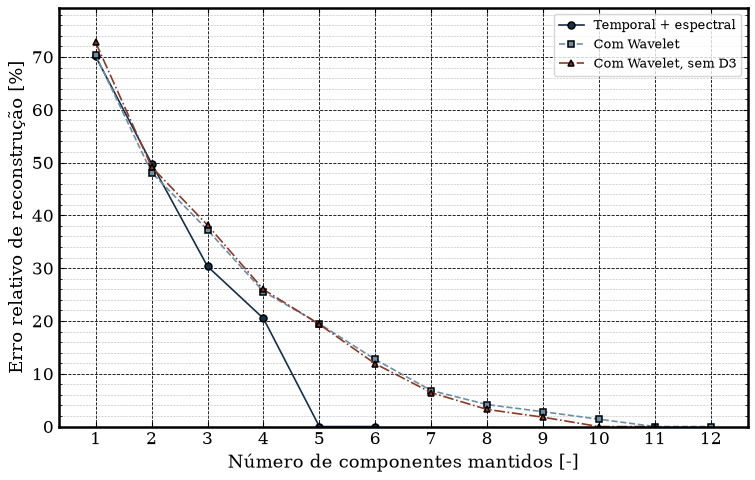

In [82]:
fig, ax = plt.subplots()

for i, nome in enumerate(cenarios):
    dados = df_reconstrucao[
        df_reconstrucao["cenario"] == nome
    ]

    ax.plot(
        dados["componentes"],
        dados["erro_relativo_percentual"],
        color=COLORS[i],
        marker=MARKERS[i],
        linestyle=["-", "--", "-."][i],
        linewidth=1.2,
        markersize=5,
        label=nome
    )

ax.set_xlabel("Número de componentes mantidos [-]")
ax.set_ylabel("Erro relativo de reconstrução [%]")
ax.set_xticks(
    np.arange(1, df_reconstrucao["componentes"].max() + 1)
)
ax.set_ylim(bottom=0)

configurar_grade(ax)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.grid(False, axis="x", which="minor")

ax.legend(fontsize=9)

salvar_figura(fig, "erro_reconstrucao_svd")
plt.show()

O erro relativo diminuiu com o aumento do nº de componentes. Com 2 PCs, ficou próximo de 50% nos três cenários, mostrando a perda associada à visualização 2D.

O conjunto temporal + espectral atingiu 90,80% da variância com 3 PCs. Nos conjuntos com Wavelet, foram necessários 4 PCs para superar 90%. A retirada de D3 alterou pouco os erros de reconstrução.

Os erros se referem à matriz de características padronizadas, não ao áudio. Como cada cenário contém características diferentes, as curvas descrevem a redução de cada conjunto e não indicam, isoladamente, qual representa melhor as falhas.

Testar outra janela de Welch e outra Wavelet, mantendo os demais parâmetros, para avaliar quanto as características mudam.

In [83]:
resultados_parametros = []

for classe in classes:
    arquivos = sorted((pasta_dados / classe).glob("*.dat"))

    for arquivo in arquivos:
        valores = np.loadtxt(arquivo, delimiter=",").ravel()

        # Welch: alterar apenas o tamanho dos trechos,
        # mantendo sobreposição de 50%.
        f_alt, psd_alt = welch(
            valores,
            fs=fs,
            window="hann",
            nperseg=2048,
            noverlap=1024,
            detrend="constant",
            scaling="density"
        )

        delta_f_alt = f_alt[1] - f_alt[0]
        total_psd = np.sum(psd_alt) * delta_f_alt

        linha = {
            "classe": classe,
            "arquivo": arquivo.name,
        }

        for inicio, fim in bandas:
            mascara = (
                (f_alt >= inicio)
                & (f_alt < fim)
            )

            if fim == fs / 2:
                mascara = (
                    (f_alt >= inicio)
                    & (f_alt <= fim)
                )

            linha[f"fracao_{inicio}_{fim}"] = (
                np.sum(psd_alt[mascara]) * delta_f_alt / total_psd
                if total_psd > 0 else np.nan
            )

        # Wavelet: alterar apenas a família/ordem utilizada.
        coef_alt = pywt.wavedec(
            valores - valores.mean(),
            wavelet="db6",
            level=6,
            mode="periodization"
        )

        energias_alt = np.array([
            np.sum(coef**2) for coef in coef_alt
        ])

        total_wavelet = energias_alt.sum()

        fracoes_alt = (
            energias_alt / total_wavelet
            if total_wavelet > 0
            else np.full(len(energias_alt), np.nan)
        )

        for nome, fracao in zip(nomes_wavelet, fracoes_alt):
            linha[f"wavelet_{nome}"] = fracao

        resultados_parametros.append(linha)

    print(f"Concluído: {classe}")

df_parametros_alt = pd.DataFrame(resultados_parametros)

df_parametros_alt.to_csv(
    pasta_resultados / "caracteristicas_parametros_alternativos.csv",
    index=False
)

Concluído: Healthy
Concluído: Bearing
Concluído: Flywheel
Concluído: LIV
Concluído: LOV
Concluído: NRV
Concluído: Piston
Concluído: Riderbelt


Comparar as características originais e alternativas por arquivo, usando correlação e diferença absoluta em pontos percentuais.

In [84]:
colunas_teste = (
    [f"fracao_{inicio}_{fim}" for inicio, fim in bandas]
    + [f"wavelet_{nome}" for nome in nomes_wavelet]
)

pares_parametros = df_features_completo[
    ["classe", "arquivo"] + colunas_teste
].merge(
    df_parametros_alt[["classe", "arquivo"] + colunas_teste],
    on=["classe", "arquivo"],
    how="outer",
    suffixes=("_original", "_alternativo"),
    validate="one_to_one",
    indicator=True
)

if not pares_parametros["_merge"].eq("both").all():
    raise ValueError("Há arquivos sem correspondência entre as análises.")

resumo_parametros = []

for coluna in colunas_teste:
    original = pares_parametros[f"{coluna}_original"].to_numpy()
    alternativo = pares_parametros[f"{coluna}_alternativo"].to_numpy()

    if not (
        np.isfinite(original).all()
        and np.isfinite(alternativo).all()
    ):
        raise ValueError(f"Valores inválidos em {coluna}")

    diferenca_pp = 100 * np.abs(alternativo - original)

    r = (
        np.corrcoef(original, alternativo)[0, 1]
        if original.std() > 0 and alternativo.std() > 0
        else np.nan
    )

    resumo_parametros.append({
        "teste": (
            "Welch: 4096 → 2048"
            if coluna.startswith("fracao_")
            else "Wavelet: db4 → db6"
        ),
        "caracteristica": coluna,
        "correlacao": r,
        "diferenca_media_pp": diferenca_pp.mean(),
        "percentil_95_diferenca_pp": np.percentile(diferenca_pp, 95),
    })

df_resumo_parametros = pd.DataFrame(resumo_parametros)

df_resumo_parametros.to_csv(
    pasta_resultados / "sensibilidade_parametros_resumo.csv",
    index=False
)

display(df_resumo_parametros.round(4))

,teste,caracteristica,correlacao,diferenca_media_pp,percentil_95_diferenca_pp
0,Welch: 4096 → 2048,fracao_0_500,0.9986,0.3460,0.9184
1,Welch: 4096 → 2048,fracao_500_1000,0.9981,0.2271,0.5998
2,Welch: 4096 → 2048,fracao_1000_2000,0.9981,0.1896,0.5351
3,Welch: 4096 → 2048,fracao_2000_4000,0.9992,0.0063,0.0176
4,Welch: 4096 → 2048,fracao_4000_8000,0.9781,0.0000,0.0000
5,Wavelet: db4 → db6,wavelet_A6,0.9901,1.2865,2.3528
6,Wavelet: db4 → db6,wavelet_D6,0.9936,1.9003,4.2755
7,Wavelet: db4 → db6,wavelet_D5,0.9861,1.3826,3.5002
8,Wavelet: db4 → db6,wavelet_D4,0.9786,0.8462,2.3663
9,Wavelet: db4 → db6,wavelet_D3,0.9920,0.3315,1.0490


A redução da janela de Welch de 4.096 para 2.048 amostras alterou pouco as frações espectrais. A maior diferença média foi 0,346 ponto percentual, na banda de 0–500 Hz.

A troca de db4 por db6 produziu mudanças maiores nos níveis A6, D6 e D5. D6 apresentou a maior diferença média, de 1,90 ponto percentual. D1 teve menor correlação entre configurações, mas pequena diferença absoluta.

Mantemos Welch com 4.096 amostras e Wavelet db4 com seis níveis como configuração de referência. O teste avalia a sensibilidade das características às alterações escolhidas; não comprova estabilidade do PCA ou superioridade desses parâmetros.